## EDA - Первичный анализ данных
**Цель:** Анализ распределения классов, проверка качества изображений, выявление проблем   
**Данные:** data/train/, data/test/ - папки с эмоциями, изображения в оттенках серого

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from collections import Counter
from pathlib import Path
from PIL import Image

from src.constants import DATA_PATH
from src.data.loader import create_dataloaders, EmotionImageDataset

In [2]:
transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((48, 48)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(f"{DATA_PATH}/train", transform=transform)
test_dataset = datasets.ImageFolder(f"{DATA_PATH}/test", transform=transform)

print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train size: 28709
Test size: 7178


In [3]:
dataset = EmotionImageDataset(DATA_PATH, split="train", image_size=48)
dataset_test = EmotionImageDataset(DATA_PATH, split="test", image_size=48)

print("Размер датасета:", len(dataset) + len(dataset_test))
print("Размер train:", len(dataset))
print("Размер test:", len(dataset_test))

img, label = dataset[0]

print("Тип изображения:", type(img))
print("Shape:", img.shape)
print("Label:", label)

Размер датасета: 35887
Размер train: 28709
Размер test: 7178
Тип изображения: <class 'torch.Tensor'>
Shape: torch.Size([1, 48, 48])
Label: 0


In [4]:
bad = 0

for i in range(len(dataset)):
    img, _ = dataset[i]
    if img is None:
        bad += 1

print("Битые изображения:", bad)

Битые изображения: 0


In [5]:
batch_size = 32
train_loader, val_loader, test_loader = create_dataloaders(DATA_PATH, batch_size=batch_size)
print("Train:", len(train_loader.dataset))
print("Val:", len(val_loader.dataset))
print("Test:", len(test_loader.dataset))

Train: 22967
Val: 5742
Test: 7178


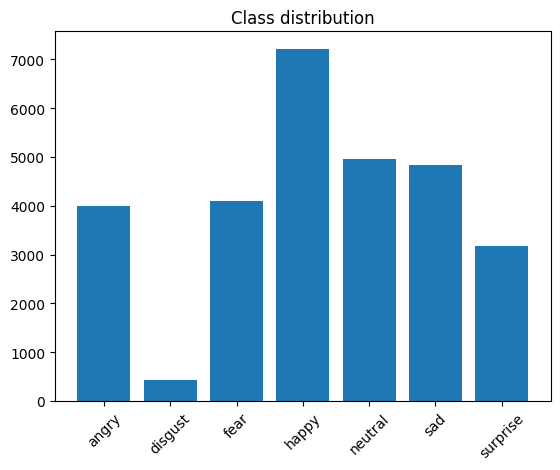

In [6]:
labels = [label for _, label in train_dataset]
counts = Counter(labels)

plt.bar(train_dataset.classes, counts.values())
plt.title("Class distribution")
plt.xticks(rotation=45)
plt.show()

Вывод: классы несбалансированы, некоторые эмоции (например, disgust) встречаются редко, а некоторые очень часто

Индекс 2: изображение полностью чёрное!
Путь: /mnt/d/AIE_course/Artificial_Intelligence_Engineering/project/data/FER-dataset/train/angry/Training_10131352.jpg
Min: 0.000, Max: 0.000, Mean: 0.000


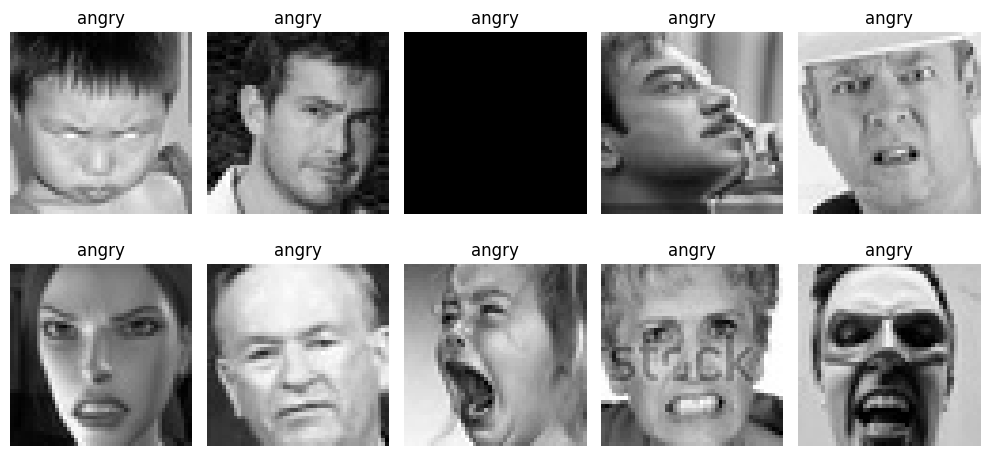

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    
    if img.max() == 0:
        print(f"Индекс {i}: изображение полностью чёрное!")
        print(f"Путь: {train_dataset.samples[i][0]}")
        print(f"Min: {img.min():.3f}, Max: {img.max():.3f}, Mean: {img.mean():.3f}")
    
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:

def find_corrupted_images(data_dir=DATA_PATH):
    corrupted = []
    for img_path in Path(data_dir).rglob("*.jpg"):
        try:
            img = Image.open(img_path)
            img.load()  # Принудительная загрузка
            
            # Проверка на пустоту
            if img.getbbox() is None or min(img.getdata()) == max(img.getdata()) == 0:
                corrupted.append((str(img_path), "empty/black"))
                
        except Exception as e:
            corrupted.append((str(img_path), str(e)))
    
    return corrupted

corrupted = find_corrupted_images()
print(f"Найдено {len(corrupted)} проблемных файлов:")
for path, reason in corrupted:
    print(f"{path}: {reason}")

Найдено 12 проблемных файлов:
  /mnt/d/AIE_course/Artificial_Intelligence_Engineering/project/data/FER-dataset/test/angry/PublicTest_5543497.jpg: empty/black
  /mnt/d/AIE_course/Artificial_Intelligence_Engineering/project/data/FER-dataset/train/angry/Training_10131352.jpg: empty/black
  /mnt/d/AIE_course/Artificial_Intelligence_Engineering/project/data/FER-dataset/train/angry/Training_28756096.jpg: empty/black
  /mnt/d/AIE_course/Artificial_Intelligence_Engineering/project/data/FER-dataset/train/angry/Training_32571770.jpg: empty/black
  /mnt/d/AIE_course/Artificial_Intelligence_Engineering/project/data/FER-dataset/train/angry/Training_52563817.jpg: empty/black
  /mnt/d/AIE_course/Artificial_Intelligence_Engineering/project/data/FER-dataset/train/angry/Training_78540321.jpg: empty/black
  /mnt/d/AIE_course/Artificial_Intelligence_Engineering/project/data/FER-dataset/train/angry/Training_96772745.jpg: empty/black
  /mnt/d/AIE_course/Artificial_Intelligence_Engineering/project/data/FER-d

Вывод: изображения маленькие (48×48) и присутствет шум. Где-то есть надписи, что тоже может портить обучение

In [8]:
means = []
stds = []

for img, _ in train_dataset:
    means.append(img.mean().item())
    stds.append(img.std().item())

print("Mean:", np.mean(means))
print("Std:", np.mean(stds))

Mean: 0.5077385789615779
Std: 0.21202472877158018
